In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Linear Regression model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional: for plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load training dataset (synthetic data)
train_df = pd.read_csv('synthetic_hri_dataset_fixed.csv')

# Load testing dataset (real-world dataset)
test_df = pd.read_csv('final_hri_modeling_dataset.csv')

In [3]:
# Define target variable (what we are predicting)
target = "hri_value"

In [4]:
# Define feature variables (predictors)
features = [
    "max_temp_celsius",
    "min_temp_celsius",
    "feat_poverty_rate",
    "feat_unemployment_rate",
    "feat_median_hh_income",
    "feat_total_population",
    "overall_homeless",
    "unsheltered_homeless"
]

In [5]:
# Split into X (features) and y (target)

# Training data
X_train = train_df[features]
y_train = train_df[target]

# Testing data
X_test = test_df[features]
y_test = test_df[target]

# Feature Exploration

1. Checking Linearity

- Target vs Features

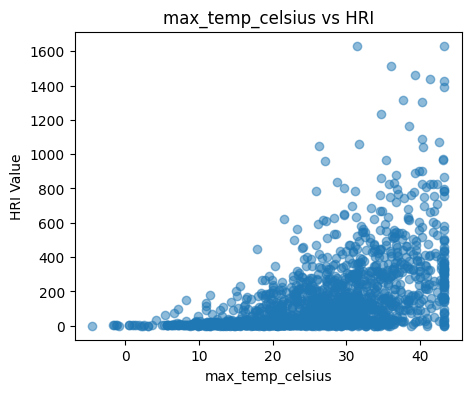

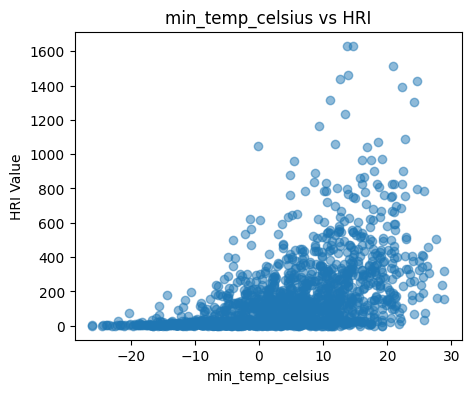

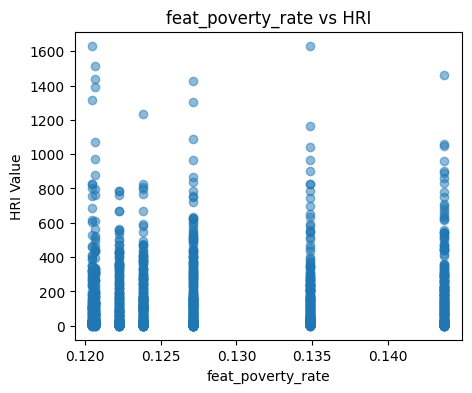

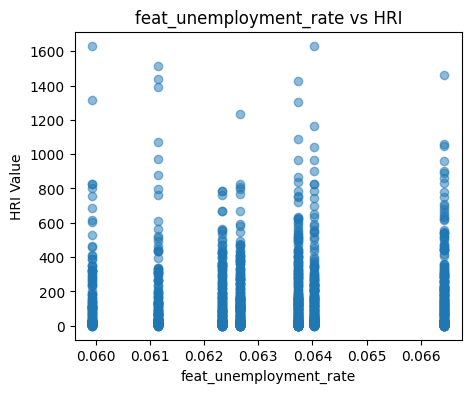

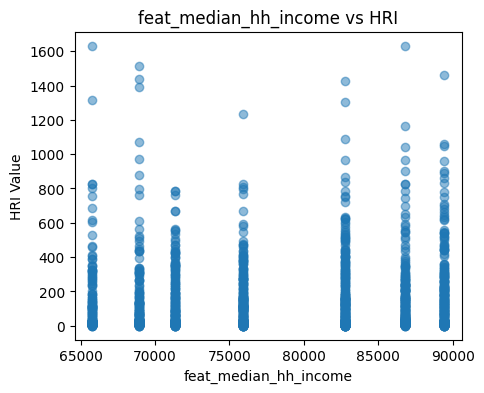

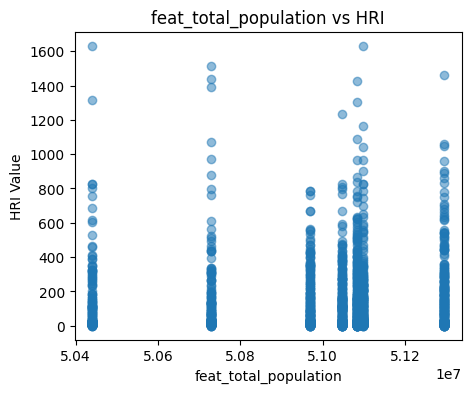

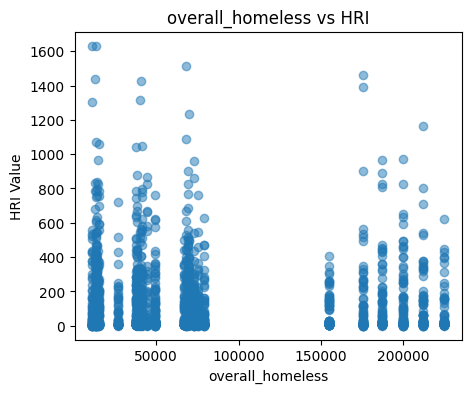

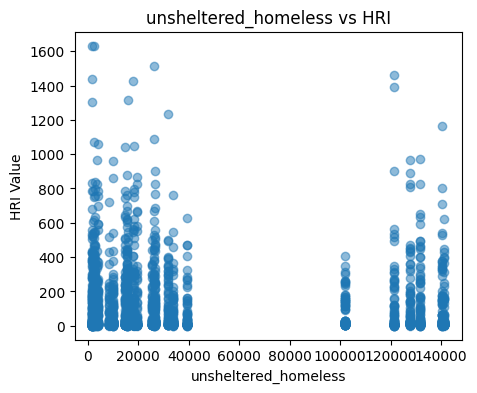

In [6]:
for col in X_train.columns:
    plt.figure(figsize=(5,4))
    plt.scatter(X_train[col], y_train, alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("HRI Value")
    plt.title(f"{col} vs HRI")
    plt.show()

In [7]:
corr = train_df.corr()

corr["hri_value"].sort_values(ascending=False)

,hri_value
hri_value,1.000000
max_temp_celsius,0.510301
min_temp_celsius,0.495919
feat_unemployment_rate,0.037473
feat_total_population,0.031987
feat_poverty_rate,0.031570
feat_median_hh_income,0.030522
unsheltered_homeless,-0.020826
overall_homeless,-0.027281


- All Features vs All Features

In [8]:
corr_matrix = train_df[features].corr()

corr_matrix

,max_temp_celsius,min_temp_celsius,feat_poverty_rate,feat_unemployment_rate,feat_median_hh_income,feat_total_population,overall_homeless,unsheltered_homeless
max_temp_celsius,1.000000,0.886276,-0.059399,-0.037762,-0.040583,-0.015392,-0.011832,-0.012461
min_temp_celsius,0.886276,1.000000,-0.035423,-0.013507,-0.015500,0.006504,-0.022899,-0.022513
feat_poverty_rate,-0.059399,-0.035423,1.000000,0.929786,0.906573,0.767501,0.039744,0.031853
feat_unemployment_rate,-0.037762,-0.013507,0.929786,1.000000,0.944212,0.937138,0.043102,0.033346
feat_median_hh_income,-0.040583,-0.015500,0.906573,0.944212,1.000000,0.883205,0.043430,0.033829
feat_total_population,-0.015392,0.006504,0.767501,0.937138,0.883205,1.000000,0.044259,0.034020
overall_homeless,-0.011832,-0.022899,0.039744,0.043102,0.043430,0.044259,1.000000,0.986253
unsheltered_homeless,-0.012461,-0.022513,0.031853,0.033346,0.033829,0.034020,0.986253,1.000000


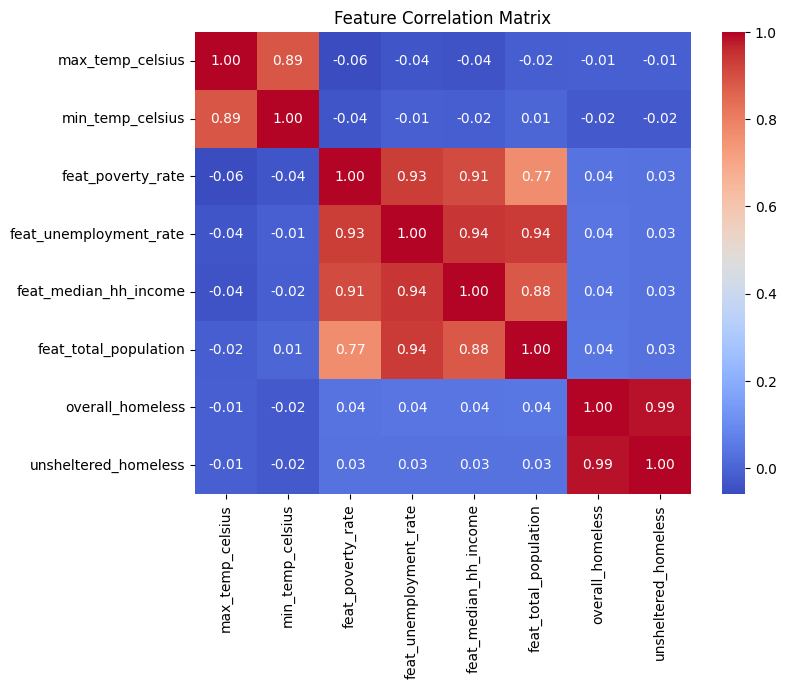

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

-> Interpretation:

We see that the features in our dataset that are a part of the same category (Temperature, Socioeconomic Factors, or Housing) are all strongly correlated to one another. We will tune the model to use only one feature from each of the categories. To select the best feature from each category, we will fit a regression model using all possible combinations and choose the combination of features (that have no more than 1 feature from each category) that has the best preformance metrics.

# Linear Combination ~ Pre-Tuning

In [10]:
# Initialize Linear Regression model
lr = LinearRegression()

In [11]:
# Train the model on synthetic data
lr.fit(X_train, y_train)

LinearRegression()

In [12]:
# Make predictions on real test data
y_pred_lr = lr.predict(X_test)

In [13]:
# Calculate performance metrics

mae_lr = mean_absolute_error(y_test, y_pred_lr)   # average error
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))  # penalizes large errors
r2_lr = r2_score(y_test, y_pred_lr)  # variance explained

print("Linear Regression Performance:")
print("MAE:", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("R²:", round(r2_lr, 3))

Linear Regression Performance:
MAE: 124.815
RMSE: 174.909
R²: 0.152


In [14]:
# Extract coefficients
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", ascending=False)

coefficients

,feature,coefficient
3,feat_unemployment_rate,25352.486259
0,max_temp_celsius,7.665275
1,min_temp_celsius,4.072611
7,unsheltered_homeless,0.001029
5,feat_total_population,-0.000119
4,feat_median_hh_income,-0.000370
6,overall_homeless,-0.000793
2,feat_poverty_rate,-933.259691


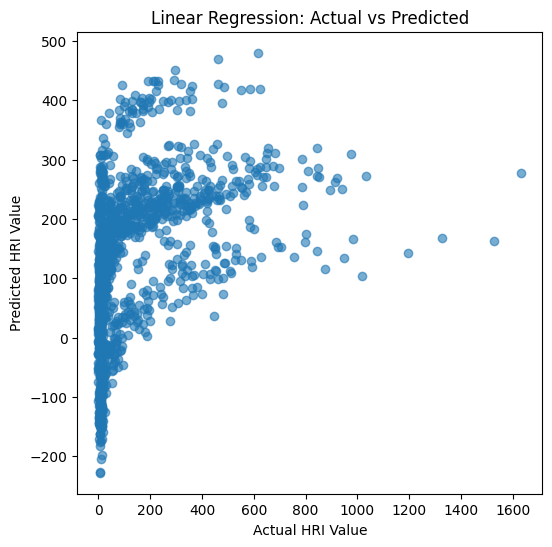

In [15]:
# Visualize Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual HRI Value")
plt.ylabel("Predicted HRI Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# Checking Model Assumptions

1. Linearity

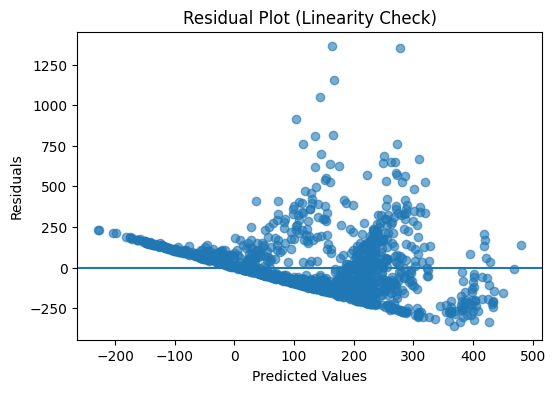

In [16]:
# Residual Plot (errors)
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linearity Check)")
plt.show()

2. Independence of Errors

In [17]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

Durbin-Watson: 0.5615579032947066


-> Assumption:

2 ~> No Autocorrelation, which is what we DO want

-> Interpretation:

0.5 ~> Positive Autocorrelation, which is NOT what we want

3. Homoscedasticity (constant variance)

In [18]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

X_with_const = sm.add_constant(X_test)
bp_test = het_breuschpagan(residuals, X_with_const)

print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 4.0474511125526494e-24


-> Assumption:

Even spread of Residual Plot & p-value > 0.05

-> Interpretation:


4. Normality of Residuals

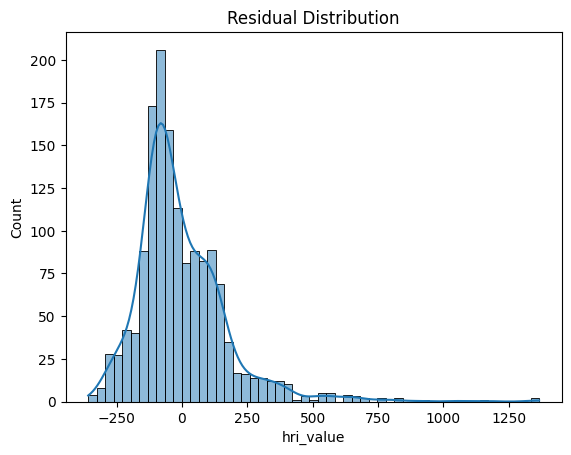

In [19]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

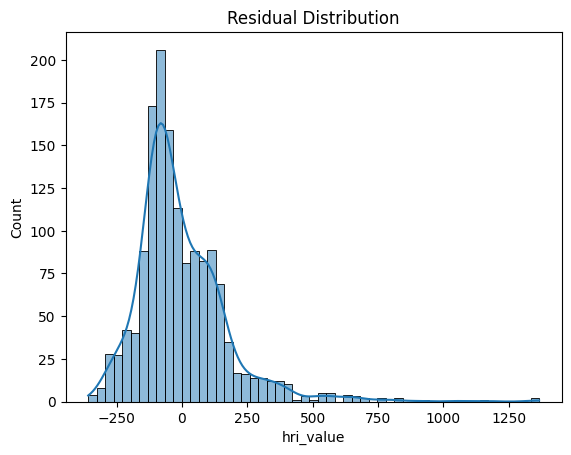

In [20]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

-> Assumption:

We want a rough bell shape / straight line, not a heavy skew

->Interpretation:



5. Multicolinearity

In [21]:
corr = X_train.corr()
print(corr)

                        max_temp_celsius  min_temp_celsius  feat_poverty_rate  \
max_temp_celsius                1.000000          0.886276          -0.059399   
min_temp_celsius                0.886276          1.000000          -0.035423   
feat_poverty_rate              -0.059399         -0.035423           1.000000   
feat_unemployment_rate         -0.037762         -0.013507           0.929786   
feat_median_hh_income          -0.040583         -0.015500           0.906573   
feat_total_population          -0.015392          0.006504           0.767501   
overall_homeless               -0.011832         -0.022899           0.039744   
unsheltered_homeless           -0.012461         -0.022513           0.031853   

                        feat_unemployment_rate  feat_median_hh_income  \
max_temp_celsius                     -0.037762              -0.040583   
min_temp_celsius                     -0.013507              -0.015500   
feat_poverty_rate                     0.929786     

-> Assumption:

Want |r| < 0.8

-> Interpretation:

Features in the same category (Temperature, Socioeconomic, or Housing) have strong correlation with one another

# Feature Reduction

Testing all possible feature combinations to see which feature produce the best performance metrics.

In [22]:
from itertools import combinations

# Store results from every feature combination
all_results = []

# Loop through every possible feature count:
# 1 feature, 2 features, 3 features, ... all 8 features
for k in range(1, len(features) + 1):

    # Generate every possible combination of k features
    for feature_combo in combinations(features, k):

        # Convert tuple to list so pandas can use it
        feature_combo = list(feature_combo)

        # Create training X using only this feature combination
        X_train_combo = train_df[feature_combo]

        # Create testing X using the same feature combination
        X_test_combo = test_df[feature_combo]

        # Target stays the same
        y_train = train_df[target]
        y_test = test_df[target]

        # Initialize Linear Regression model
        model = LinearRegression()

        # Train on synthetic data
        model.fit(X_train_combo, y_train)

        # Predict on real data
        y_pred_combo = model.predict(X_test_combo)

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred_combo)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_combo))
        r2 = r2_score(y_test, y_pred_combo)

        # Save the results
        all_results.append({
            "num_features": k,
            "features_used": feature_combo,
            "mae": mae,
            "rmse": rmse,
            "r2": r2
        })

In [23]:
# Convert all results into a dataframe
combo_results = pd.DataFrame(all_results)

# Sort by RMSE because RMSE is your main metric
combo_results_sorted = combo_results.sort_values("rmse").reset_index(drop=True)

# Show best 10 combinations
combo_results_sorted.head(10)

,num_features,features_used,mae,rmse,r2
0,3,"[min_temp_celsius, feat_median_hh_income, feat...",98.011937,148.435691,0.389555
1,2,"[min_temp_celsius, feat_median_hh_income]",98.018568,148.503550,0.388996
2,2,"[min_temp_celsius, feat_total_population]",98.256546,148.873869,0.385945
3,4,"[min_temp_celsius, feat_median_hh_income, feat...",98.948976,149.164207,0.383548
4,3,"[min_temp_celsius, feat_median_hh_income, unsh...",98.964790,149.240569,0.382917
5,1,[min_temp_celsius],98.725101,149.360927,0.381921
6,3,"[min_temp_celsius, feat_total_population, unsh...",99.192508,149.597036,0.379965
7,4,"[min_temp_celsius, feat_median_hh_income, feat...",99.558041,149.631014,0.379683
8,3,"[min_temp_celsius, feat_median_hh_income, over...",99.578232,149.709938,0.379029
9,5,"[min_temp_celsius, feat_median_hh_income, feat...",99.727113,149.751570,0.378684


In [24]:
list(combo_results_sorted.iloc[0:5, 1])

[['min_temp_celsius', 'feat_median_hh_income', 'feat_total_population'],
 ['min_temp_celsius', 'feat_median_hh_income'],
 ['min_temp_celsius', 'feat_total_population'],
 ['min_temp_celsius',
  'feat_median_hh_income',
  'feat_total_population',
  'unsheltered_homeless'],
 ['min_temp_celsius', 'feat_median_hh_income', 'unsheltered_homeless']]

For the goal of our analysis, to predict HRI using Temperature, Socioeconomic Factors, and Housing factors, we chose the combination of reduced features where no more than 1 feature for each category is present (due to multicolinearity as explained earlier). There were 2 feature options that had similar performance metrics, but we wanted to include all categories and the differences in their performances were very minimal.

# Final Model Selected for Linear Regression

In [25]:
best_features = ['min_temp_celsius', 'feat_median_hh_income', 'unsheltered_homeless']

In [26]:
# Create training and testing datasets

# Training data (synthetic dataset)
X_train_best = train_df[best_features]
y_train = train_df[target]

# Testing data (real dataset)
X_test_best = test_df[best_features]
y_test = test_df[target]

In [27]:
# Initialize Linear Regression model
lr_best = LinearRegression()

# Train model on synthetic data
lr_best.fit(X_train_best, y_train)

LinearRegression()

In [28]:
# Make predictions on real test data
y_pred_best = lr_best.predict(X_test_best)

In [29]:
# Calculate metrics

mae_best = mean_absolute_error(y_test, y_pred_best)  # average error
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))  # penalizes large errors
r2_best = r2_score(y_test, y_pred_best)  # variance explained

print("Final Linear Regression Performance:")
print("MAE:", round(mae_best, 3))
print("RMSE:", round(rmse_best, 3))
print("R²:", round(r2_best, 3))

Final Linear Regression Performance:
MAE: 98.965
RMSE: 149.241
R²: 0.383


In [30]:
# View model coefficients
coefficients_best = pd.DataFrame({
    "feature": best_features,
    "coefficient": lr_best.coef_
})

coefficients_best

,feature,coefficient
0,min_temp_celsius,10.258566
1,feat_median_hh_income,0.000942
2,unsheltered_homeless,-0.000046


-> Interpretation:

Positive -> Increases HRI
Negative -> Decreases HRI

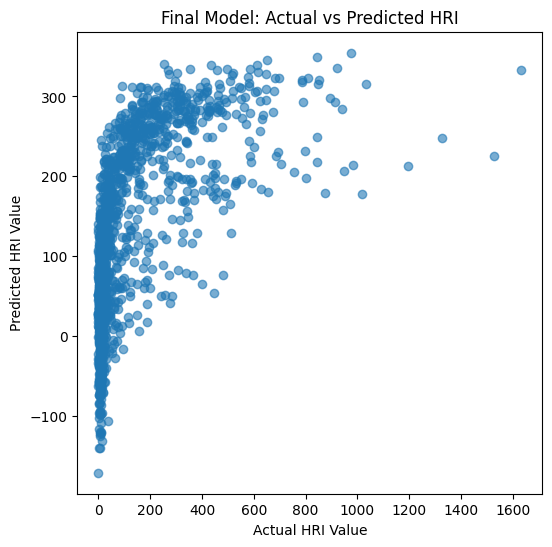

In [31]:
#Actual vs Predicted Visual Check

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.xlabel("Actual HRI Value")
plt.ylabel("Predicted HRI Value")
plt.title("Final Model: Actual vs Predicted HRI")
plt.show()

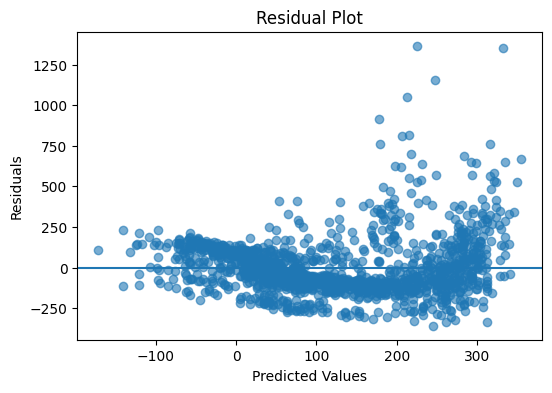

In [32]:
#Residual Plot (Assumption Check)

# Calculate residuals (errors)
residuals_best = y_test - y_pred_best

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

-> Interpretation:

There are 2 issues:

1. Heteroscedasticity (variance problem)
       The left side has a tight spread
       The right side has a fan shape, larger spread
       Thus, variance increases as predictions increase
       The model is much less accurate for high HRI values
2. Pattern/Slight Curvature
        Risudals dip negative in the middle, then spread upward again
        Thus, the model is missing some nonlinear structure
        
Solution: try a log transformation of our target variable, hri_value

# Log Transformation of Best Linear Model

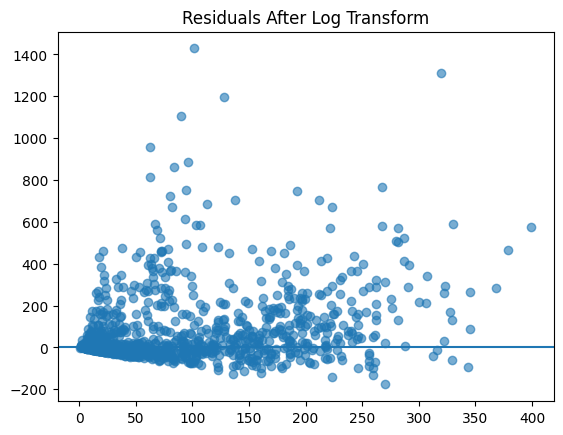

In [33]:
# Transform target
y_train_log = np.log1p(y_train)

# Train model
lr_log = LinearRegression()
lr_log.fit(X_train_best, y_train_log)

# Predict and convert back
y_pred_log = lr_log.predict(X_test_best)
y_pred2 = np.expm1(y_pred_log)

# Residuals
residuals = y_test - y_pred2

# Plot again
plt.scatter(y_pred2, residuals, alpha=0.6)
plt.axhline(0)
plt.title("Residuals After Log Transform")
plt.show()

In [34]:
mae_log = mean_absolute_error(y_test, y_pred2)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_log = r2_score(y_test, y_pred2)

print("Log Model Performance:")
print("MAE:", round(mae_log, 3))
print("RMSE:", round(rmse_log, 3))
print("R²:", round(r2_log, 3))

Log Model Performance:
MAE: 73.259
RMSE: 157.934
R²: 0.309


-> Interpretation:

Residual Plot Analysis Shows:
     - Still heteroscedasticity
     - Still spread increasing
     - Slight improvement near low values
     - BUT still messy at higher values
Performance Metrics Show:
    - MAE improved (73 vs 98.9)
        - Better at average error
    - RMSE increased (157.9 vs 149.2)
        - Worse at large errors
    - R^2 decreased (0.309 vs 0.383)
        - Explains less variation
        
RMSE matters more than MAE, since accurately predicting extreme heat-related illness levels is critical.

Thus, Log Transformation did NOT fix the core problem.

# Attempting Additional Transformations

In [35]:
# ------------------------------------------------------------
# 1. Define target and original selected features
# ------------------------------------------------------------

target = "hri_value"

best_features = [
    "min_temp_celsius",
    "feat_median_hh_income",
    "unsheltered_homeless"
]

X_train_best = train_df[best_features]
X_test_best = test_df[best_features]

y_train = train_df[target]
y_test = test_df[target]

In [36]:
# ------------------------------------------------------------
# 2. Helper function to train + evaluate any Linear Regression model
# ------------------------------------------------------------

def evaluate_linear_model(model_name, train_data, test_data, feature_list):
    """
    Trains Linear Regression using selected features,
    predicts on real test data, and returns MAE, RMSE, R².
    """

    X_train_model = train_data[feature_list]
    X_test_model = test_data[feature_list]

    model = LinearRegression()
    model.fit(X_train_model, y_train)

    predictions = model.predict(X_test_model)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(f"\n{model_name}")
    print("Features:", feature_list)
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²:", round(r2, 3))

    return {
        "model": model_name,
        "features": feature_list,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "trained_model": model,
        "predictions": predictions
    }

In [37]:
# ------------------------------------------------------------
# 3. Original 3-feature model
# ------------------------------------------------------------

results = []

original_result = evaluate_linear_model(
    model_name="Original 3-Feature Linear Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=best_features
)

results.append(original_result)


Original 3-Feature Linear Model
Features: ['min_temp_celsius', 'feat_median_hh_income', 'unsheltered_homeless']
MAE: 98.965
RMSE: 149.241
R²: 0.383


In [38]:
# ------------------------------------------------------------
# 4. Polynomial temperature model
# Adds min_temp_celsius squared to capture curvature
# ------------------------------------------------------------

train_df["min_temp_sq"] = train_df["min_temp_celsius"] ** 2
test_df["min_temp_sq"] = test_df["min_temp_celsius"] ** 2

poly_features = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "unsheltered_homeless"
]

poly_result = evaluate_linear_model(
    model_name="Polynomial Temp Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=poly_features
)

results.append(poly_result)


Polynomial Temp Model
Features: ['min_temp_celsius', 'min_temp_sq', 'feat_median_hh_income', 'unsheltered_homeless']
MAE: 86.276
RMSE: 141.728
R²: 0.443


-> Why we did this:

We added a polynomial term for temperature to capture nonlinear effects, as our previous residual analysis suggested curvature in the relationship between temperature and heat-related illness.

In [39]:
# ------------------------------------------------------------
# 5. Log-transform unsheltered homelessness
# Reduces skew/outlier effect in homelessness variable
# ------------------------------------------------------------

train_df["log_unsheltered_homeless"] = np.log1p(train_df["unsheltered_homeless"])
test_df["log_unsheltered_homeless"] = np.log1p(test_df["unsheltered_homeless"])

log_feature_model_features = [
    "min_temp_celsius",
    "feat_median_hh_income",
    "log_unsheltered_homeless"
]

log_feature_result = evaluate_linear_model(
    model_name="Log Unsheltered Feature Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=log_feature_model_features
)

results.append(log_feature_result)


Log Unsheltered Feature Model
Features: ['min_temp_celsius', 'feat_median_hh_income', 'log_unsheltered_homeless']
MAE: 99.478
RMSE: 149.629
R²: 0.38


-> Why we did this:

We applied a log transformation to unsheltered homelessness counts in order to reduce skewness and limit the influence of extreme values.

In [40]:
# ------------------------------------------------------------
# 6. Interaction term: temperature × income
# Tests whether temperature effect changes by income level
# ------------------------------------------------------------

train_df["temp_income_interaction"] = (
    train_df["min_temp_celsius"] * train_df["feat_median_hh_income"]
)

test_df["temp_income_interaction"] = (
    test_df["min_temp_celsius"] * test_df["feat_median_hh_income"]
)

interaction_features = [
    "min_temp_celsius",
    "feat_median_hh_income",
    "unsheltered_homeless",
    "temp_income_interaction"
]

interaction_result = evaluate_linear_model(
    model_name="Temperature × Income Interaction Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=interaction_features
)

results.append(interaction_result)


Temperature × Income Interaction Model
Features: ['min_temp_celsius', 'feat_median_hh_income', 'unsheltered_homeless', 'temp_income_interaction']
MAE: 98.717
RMSE: 148.842
R²: 0.386


-> Why we did this:

Low-income populations may be more vulnerable to heat, so we introduced an interaction term between temperature and median income to capture potential differences in heat vulnerability across socioeconomic groups.

In [41]:
# ------------------------------------------------------------
# 7. Combined engineered model
# Includes polynomial temp, log homelessness, and interaction
# ------------------------------------------------------------

combined_features = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "log_unsheltered_homeless",
    "temp_income_interaction"
]

combined_result = evaluate_linear_model(
    model_name="Combined Engineered Linear Model",
    train_data=train_df,
    test_data=test_df,
    feature_list=combined_features
)

results.append(combined_result)


Combined Engineered Linear Model
Features: ['min_temp_celsius', 'min_temp_sq', 'feat_median_hh_income', 'log_unsheltered_homeless', 'temp_income_interaction']
MAE: 86.209
RMSE: 141.393
R²: 0.446


-> Why we tried this:

We evaluated a combined model incorporating polynomial, log-transformed, and interaction features to capture nonlinear relationships, reduce skewness, and account for interaction effects between variables.

In [42]:
# ------------------------------------------------------------
# 8. Compare all transformation results
# ------------------------------------------------------------

comparison_df = pd.DataFrame([
    {
        "model": r["model"],
        "num_features": len(r["features"]),
        "features": r["features"],
        "mae": r["mae"],
        "rmse": r["rmse"],
        "r2": r["r2"]
    }
    for r in results
])

comparison_df = comparison_df.sort_values("rmse").reset_index(drop=True)

comparison_df

,model,num_features,features,mae,rmse,r2
0,Combined Engineered Linear Model,5,"[min_temp_celsius, min_temp_sq, feat_median_hh...",86.209439,141.393450,0.446103
1,Polynomial Temp Model,4,"[min_temp_celsius, min_temp_sq, feat_median_hh...",86.275848,141.728151,0.443478
2,Temperature × Income Interaction Model,4,"[min_temp_celsius, feat_median_hh_income, unsh...",98.716726,148.842212,0.386206
3,Original 3-Feature Linear Model,3,"[min_temp_celsius, feat_median_hh_income, unsh...",98.964790,149.240569,0.382917
4,Log Unsheltered Feature Model,3,"[min_temp_celsius, feat_median_hh_income, log_...",99.478118,149.628901,0.379701


-> Interpretation:

The engineered linear model achieved the best performance, reducing RMSE from approximately 149 to 141. This improvement was primarily driven by the inclusion of a polynomial temperature term, indicating a nonlinear relationship between temperature and heat-related illness. Other transformations, such as interaction and log transformations, did not improve performance, suggesting that nonlinearity in temperature is the dominant factor.”

In [43]:
# ------------------------------------------------------------
# 9. Select best model based on RMSE
# ------------------------------------------------------------

best_result = min(results, key=lambda x: x["rmse"])

best_model_name = best_result["model"]
best_model = best_result["trained_model"]
best_predictions = best_result["predictions"]
best_features_final = best_result["features"]

print("Best Model Based on RMSE:")
print(best_model_name)
print("Features:", best_features_final)
print("RMSE:", round(best_result["rmse"], 3))
print("MAE:", round(best_result["mae"], 3))
print("R²:", round(best_result["r2"], 3))

Best Model Based on RMSE:
Combined Engineered Linear Model
Features: ['min_temp_celsius', 'min_temp_sq', 'feat_median_hh_income', 'log_unsheltered_homeless', 'temp_income_interaction']
RMSE: 141.393
MAE: 86.209
R²: 0.446


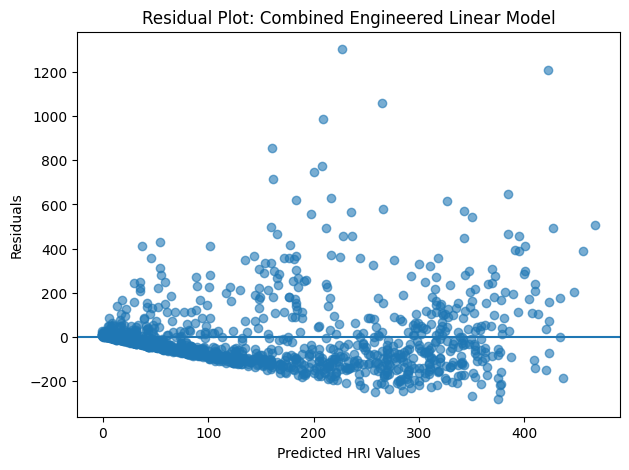

In [44]:
# ------------------------------------------------------------
# 10. Plot residuals for best model
# ------------------------------------------------------------

best_residuals = y_test - best_predictions

plt.figure(figsize=(7,5))
plt.scatter(best_predictions, best_residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted HRI Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {best_model_name}")
plt.show()

-> Interpretation:

The residual plot for the engineered linear model shows that:
    - Residuals are generally centered around zero, indicating that the model is not systematically overpredicting or underpredicting across most values.
    - There is still evidence of heteroscedasticity, as the spread of residuals increases for higher predicted HRI values. T
    
This suggests that the model has more difficulty accurately predicting extreme heat-related illness levels.

Despite this, the overall randomness of the residual distribution and improved model performance indicate that the engineered model provides a better fit than the original.

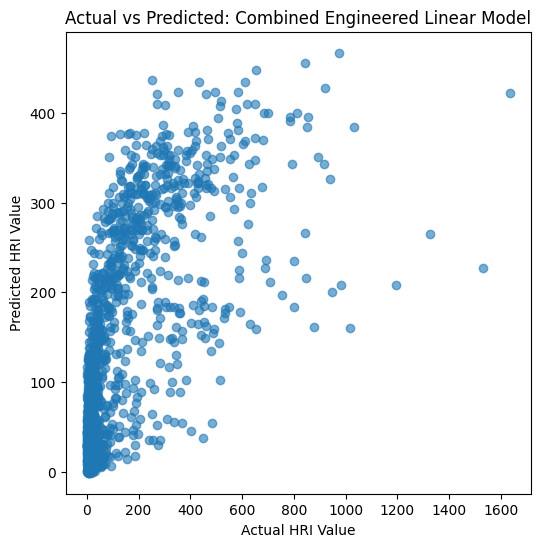

In [45]:
# ------------------------------------------------------------
# 11. Plot actual vs predicted for best model
# ------------------------------------------------------------

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_predictions, alpha=0.6)
plt.xlabel("Actual HRI Value")
plt.ylabel("Predicted HRI Value")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.show()

-> Interpretation:

The Actual vs Predicted plot demonstrates:
    - A clear positive relationship between predicted and actual HRI values, indicating that the model is capturing the general trend in the data.
    - Most points cluster along an upward pattern, showing that higher actual values tend to correspond with higher predicted values.
    - However, the model tends to underestimate very high HRI values, as seen by the compression of predictions at the upper range.
    
This suggests that while the model performs well overall, it struggles to fully capture extreme spikes in heat-related illness.

In [46]:
# ------------------------------------------------------------
# 12. Coefficients for best model
# ------------------------------------------------------------

coefficients = pd.DataFrame({
    "feature": best_features_final,
    "coefficient": best_model.coef_
}).sort_values("coefficient", ascending=False)

coefficients

,feature,coefficient
0,min_temp_celsius,4.171478
1,min_temp_sq,0.279797
2,feat_median_hh_income,0.000845
4,temp_income_interaction,0.000057
3,log_unsheltered_homeless,-2.621654


-> Interpretation:

The model coefficients provide insight into how each feature influences predicted heat-related illness (HRI).
    
    - Minimum temperature has the largest positive effect, indicating that higher temperatures are strongly associated with increased HRI.

    - The positive coefficient on the squared temperature term confirms a nonlinear relationship, where the effect of temperature intensifies at higher levels.
    
    - Median household income has a small positive coefficient, suggesting a slight association with HRI, though its effect is relatively minor.
    
    - The interaction term between temperature and income is also small, indicating limited combined effect.
    
    - The negative coefficient for log-transformed unsheltered homelessness suggests that, after accounting for other variables, higher homelessness levels are associated with lower predicted HRI, though this may reflect underlying data relationships rather than a direct causal effect.

# Saving Best Model as a pkl file

In [47]:
# ============================================================
# SAVE BEST MODEL FILES FOR STREAMLIT DEPLOYMENT
# ============================================================

import pickle
import json

In [70]:
# ------------------------------------------------------------
# 1. Define final best model features
# These MUST match the exact order used for training/prediction.
# ------------------------------------------------------------

best_features_final = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "log_unsheltered_homeless",
    "temp_income_interaction"
]

target = "hri_value"

In [71]:
# ------------------------------------------------------------
# 2. Make sure engineered features exist
# If they already exist, this just overwrites them safely.
# ------------------------------------------------------------

# Polynomial temperature feature
train_df["min_temp_sq"] = train_df["min_temp_celsius"] ** 2
test_df["min_temp_sq"] = test_df["min_temp_celsius"] ** 2

# Log-transformed homelessness feature
train_df["log_unsheltered_homeless"] = np.log1p(train_df["unsheltered_homeless"])
test_df["log_unsheltered_homeless"] = np.log1p(test_df["unsheltered_homeless"])

# Temperature × income interaction
train_df["temp_income_interaction"] = (
    train_df["min_temp_celsius"] * train_df["feat_median_hh_income"]
)

test_df["temp_income_interaction"] = (
    test_df["min_temp_celsius"] * test_df["feat_median_hh_income"]
)

In [72]:
# ------------------------------------------------------------
# 3. Create X and y using final feature set
# Train = synthetic data
# Test = real final modeling dataset
# ------------------------------------------------------------

X_train_final = train_df[best_features_final]
y_train = train_df[target]

X_test_final = test_df[best_features_final]
y_test = test_df[target]

In [73]:
# ------------------------------------------------------------
# 3. Create X and y using final feature set
# Train = synthetic data
# Test = real final modeling dataset
# ------------------------------------------------------------

X_train_final = train_df[best_features_final]
y_train = train_df[target]

X_test_final = test_df[best_features_final]
y_test = test_df[target]

In [74]:
# ------------------------------------------------------------
# 4. Train final best model
# This is the model you selected based on best RMSE.
# ------------------------------------------------------------

best_model = LinearRegression()
best_model.fit(X_train_final, y_train)

LinearRegression()

In [75]:
# ------------------------------------------------------------
# 5. Evaluate final model on real test data
# ------------------------------------------------------------

y_pred_final = best_model.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print("Final Engineered Linear Model Performance")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

Final Engineered Linear Model Performance
MAE: 86.209
RMSE: 141.393
R²: 0.446


In [76]:
# ------------------------------------------------------------
# 6. Save trained model as .pkl
# This is what your teammate needs for Streamlit predictions.
# ------------------------------------------------------------

with open("best_engineered_linear_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Saved: best_engineered_linear_model.pkl")

Saved: best_engineered_linear_model.pkl


In [77]:
# ------------------------------------------------------------
# 7. Save feature-order list as JSON
# This prevents prediction errors in Streamlit.
# The app must use this exact feature order.
# ------------------------------------------------------------

with open("feature_cols.json", "w") as f:
    json.dump(best_features_final, f, indent=4)

print("Saved: feature_cols.json")

Saved: feature_cols.json


In [78]:
# ------------------------------------------------------------
# 8. Save metrics as JSON
# Useful for displaying model performance in Streamlit.
# ------------------------------------------------------------

metrics = {
    "model_name": "Engineered Linear Regression",
    "mae": float(mae),
    "rmse": float(rmse),
    "r2": float(r2),
    "train_data": "synthetic_hri_dataset.csv",
    "test_data": "final_hri_modeling_dataset.csv",
    "feature_cols": best_features_final
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved: metrics.json")

Saved: metrics.json


In [79]:
# ------------------------------------------------------------
# 9. Save metrics as CSV too
# Some people prefer CSV for easy viewing.
# ------------------------------------------------------------

metrics_df = pd.DataFrame([{
    "model_name": "Engineered Linear Regression",
    "mae": mae,
    "rmse": rmse,
    "r2": r2,
    "num_features": len(best_features_final)
}])

metrics_df.to_csv("metrics.csv", index=False)

print("Saved: metrics.csv")

Saved: metrics.csv


In [80]:
# ------------------------------------------------------------
# 10. Save sample input + expected output
# This helps your teammate test the Streamlit pipeline.
# ------------------------------------------------------------

sample = X_test_final.iloc[[0]].copy()

sample["expected_prediction"] = best_model.predict(sample)[0]
sample["actual_hri_value"] = y_test.iloc[0]

sample.to_csv("sample_input_output.csv", index=False)

sample

,min_temp_celsius,min_temp_sq,feat_median_hh_income,log_unsheltered_homeless,temp_income_interaction,expected_prediction,actual_hri_value
0,-2.1,4.41,65780.75,10.17126,-138139.575,44.321871,4


In [81]:
# ------------------------------------------------------------
# 11. Optional: save all test predictions
# Useful for validation and reporting.
# ------------------------------------------------------------

predictions_df = test_df.copy()
predictions_df["predicted_hri_value"] = y_pred_final
predictions_df["prediction_error"] = predictions_df["hri_value"] - predictions_df["predicted_hri_value"]

predictions_df.to_csv("best_model_predictions.csv", index=False)

print("Saved: best_model_predictions.csv")

Saved: best_model_predictions.csv


In [82]:
# ------------------------------------------------------------
# 12. Confirm all files were created
# ------------------------------------------------------------

import os

files_to_check = [
    "best_engineered_linear_model.pkl",
    "feature_cols.json",
    "metrics.json",
    "metrics.csv",
    "sample_input_output.csv",
    "best_model_predictions.csv"
]

for file in files_to_check:
    print(file, "exists:", os.path.exists(file))

best_engineered_linear_model.pkl exists: True
feature_cols.json exists: True
metrics.json exists: True
metrics.csv exists: True
sample_input_output.csv exists: True
best_model_predictions.csv exists: True


# Checking Assumptions of Final Best Model

In [48]:
# ============================================================
# LINEAR REGRESSION ASSUMPTION CHECKS FOR BEST MODEL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [49]:
# ------------------------------------------------------------
# 1. Define best model features
# ------------------------------------------------------------

best_features_final = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "log_unsheltered_homeless",
    "temp_income_interaction"
]

target = "hri_value"

X_train_best = train_df[best_features_final]
X_test_best = test_df[best_features_final]

y_train = train_df[target]
y_test = test_df[target]

In [50]:
# ------------------------------------------------------------
# 2. Fit best linear model
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression

best_lr = LinearRegression()
best_lr.fit(X_train_best, y_train)

y_pred = best_lr.predict(X_test_best)
residuals = y_test - y_pred

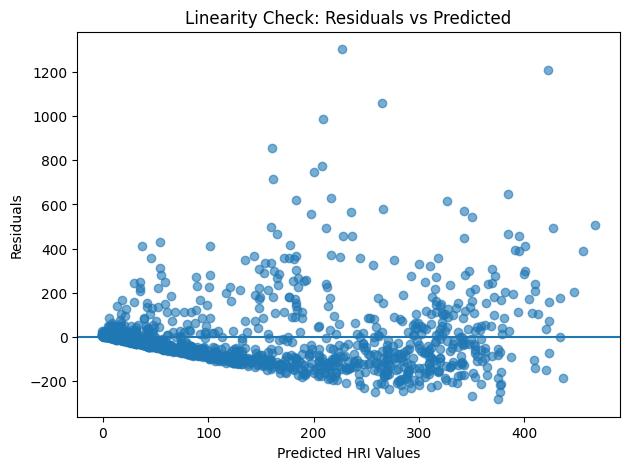

In [51]:
# ------------------------------------------------------------
# 3. Assumption 1: Linearity
# Residuals should be randomly scattered around 0
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted HRI Values")
plt.ylabel("Residuals")
plt.title("Linearity Check: Residuals vs Predicted")
plt.show()

In [52]:
# ------------------------------------------------------------
# 4. Assumption 2: Homoscedasticity
# Breusch-Pagan test checks whether residual variance is constant.
# p-value > 0.05 = no strong evidence of heteroscedasticity.
# p-value <= 0.05 = heteroscedasticity likely exists.
# ------------------------------------------------------------

X_test_const = sm.add_constant(X_test_best)

bp_test = het_breuschpagan(residuals, X_test_const)

bp_results = {
    "LM Statistic": bp_test[0],
    "LM p-value": bp_test[1],
    "F Statistic": bp_test[2],
    "F p-value": bp_test[3]
}

bp_results

{'LM Statistic': np.float64(118.43594525085867),
 'LM p-value': np.float64(6.729130058658378e-24),
 'F Statistic': np.float64(25.672402862187482),
 'F p-value': np.float64(6.800611058562838e-25)}

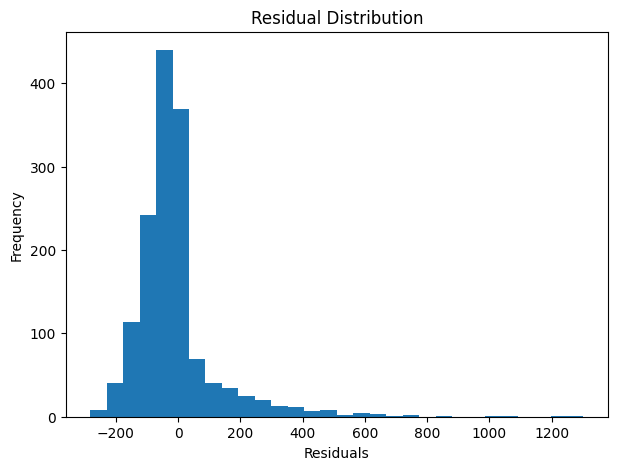

In [53]:
# ------------------------------------------------------------
# 5. Assumption 3: Normality of residuals
# Histogram should look roughly bell-shaped.
# Q-Q plot points should roughly follow the diagonal line.
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

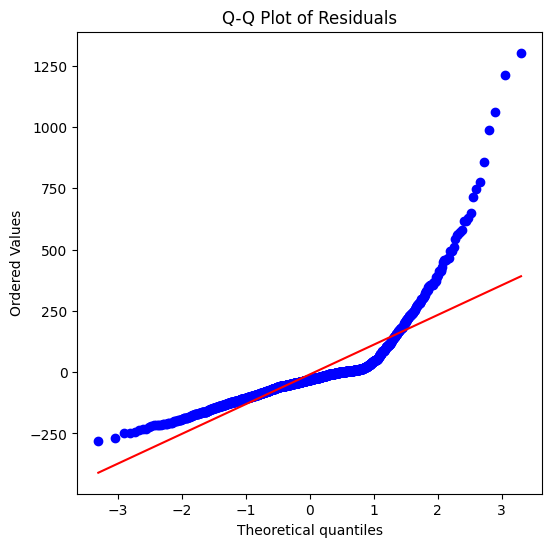

In [54]:
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [55]:
# Optional formal normality test
# p-value > 0.05 suggests residuals are approximately normal
# p-value <= 0.05 suggests residuals are not normally distributed

shapiro_stat, shapiro_p = stats.shapiro(residuals.sample(500, random_state=42) if len(residuals) > 500 else residuals)

print("Shapiro-Wilk Test")
print("Statistic:", round(shapiro_stat, 4))
print("p-value:", round(shapiro_p, 4))

Shapiro-Wilk Test
Statistic: 0.7489
p-value: 0.0


In [56]:
# ------------------------------------------------------------
# 6. Assumption 4: Independence of errors
# Durbin-Watson checks autocorrelation in residuals.
# Around 2 = good
# < 1.5 = positive autocorrelation
# > 2.5 = negative autocorrelation
# ------------------------------------------------------------

dw_stat = durbin_watson(residuals)

print("Durbin-Watson Statistic:", round(dw_stat, 4))

Durbin-Watson Statistic: 0.7549


In [57]:
# ------------------------------------------------------------
# 7. Assumption 5: Multicollinearity
# VIF checks whether features are highly redundant.
# VIF < 5 = acceptable
# VIF 5-10 = moderate concern
# VIF > 10 = serious multicollinearity
# ------------------------------------------------------------

X_vif = sm.add_constant(X_train_best)

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df

,feature,VIF
0,const,143.082347
1,min_temp_celsius,93.256512
2,min_temp_sq,1.203382
3,feat_median_hh_income,1.083494
4,log_unsheltered_homeless,1.005464
5,temp_income_interaction,92.580302


In [58]:
# ------------------------------------------------------------
# 8. Summary table for assumptions
# ------------------------------------------------------------

assumption_summary = pd.DataFrame({
    "Assumption": [
        "Linearity",
        "Homoscedasticity",
        "Normality of residuals",
        "Independence of errors",
        "Multicollinearity"
    ],
    "How Checked": [
        "Residuals vs Predicted Plot",
        "Breusch-Pagan Test",
        "Histogram, Q-Q Plot, Shapiro-Wilk Test",
        "Durbin-Watson Statistic",
        "Variance Inflation Factor (VIF)"
    ],
    "Rule of Thumb": [
        "Random scatter around 0",
        "p-value > 0.05",
        "Bell-shaped residuals / Q-Q line / p-value > 0.05",
        "Statistic close to 2",
        "VIF < 5 preferred"
    ]
})

assumption_summary

,Assumption,How Checked,Rule of Thumb
0,Linearity,Residuals vs Predicted Plot,Random scatter around 0
1,Homoscedasticity,Breusch-Pagan Test,p-value > 0.05
2,Normality of residuals,"Histogram, Q-Q Plot, Shapiro-Wilk Test",Bell-shaped residuals / Q-Q line / p-value > 0.05
3,Independence of errors,Durbin-Watson Statistic,Statistic close to 2
4,Multicollinearity,Variance Inflation Factor (VIF),VIF < 5 preferred


-> Interpretation:

The linear regression assumptions were evaluated using residual diagnostics and statistical tests.

The results indicate that several classical assumptions are not fully satisfied.
    - In particular, strong heteroscedasticity, non-normal residuals, and multicollinearity were observed, along with evidence of autocorrelation in residuals.

While linearity is partially satisfied, the presence of nonlinear patterns suggests that the relationship between predictors and the target is not strictly linear.

Despite these violations, the model demonstrates strong predictive performance, and linear regression is known to be robust to moderate assumption violations in predictive settings.

Therefore, the model is considered appropriate for prediction, though results should be interpreted with these limitations in mind.

Key Takeaway: The model is NOT a perfect statistical model
BUT it IS a strong predictive model.

# SHAP Analysis

1. Install SHAP (if needed)

In [59]:
#!pip install shap

2. Import SHAP

In [60]:
import shap

# initialize JS for visualization
shap.initjs()

3. Prepare the data using the same features the model was trained on

In [61]:
best_features_final = [
    "min_temp_celsius",
    "min_temp_sq",
    "feat_median_hh_income",
    "log_unsheltered_homeless",
    "temp_income_interaction"
]

X_train_best = train_df[best_features_final]
X_test_best = test_df[best_features_final]

4. Create SHAP explainer

In [62]:
explainer = shap.LinearExplainer(best_model, X_train_best)

5. Compute SHAP values

In [63]:
shap_values = explainer.shap_values(X_test_best)

6. FORCE Plot (horizontal - single observation)

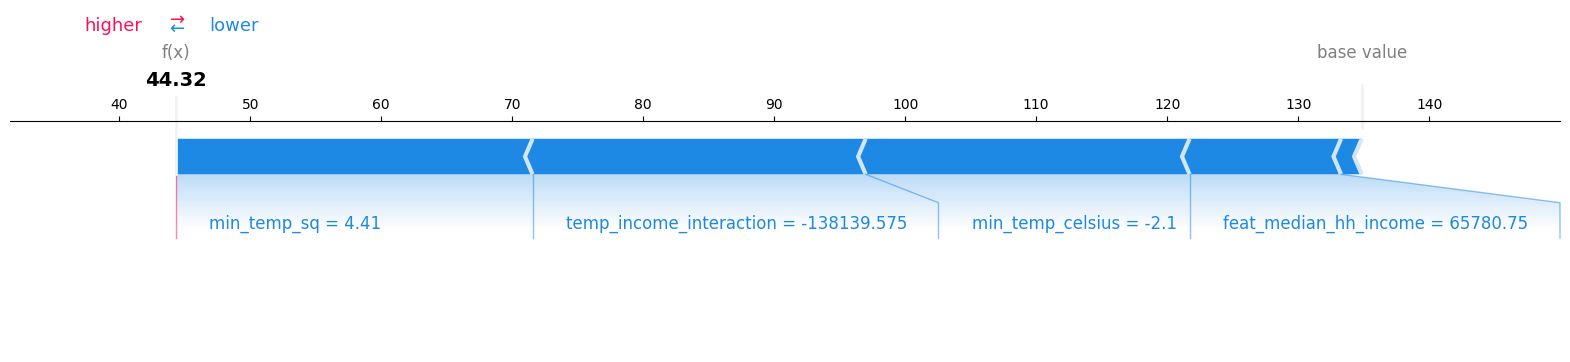

In [64]:
i = 0  # change this to explore different observations

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test_best.iloc[i],
     matplotlib=True
)

7. Summary Plot

This gives:

- global feature importance
- direction of impact

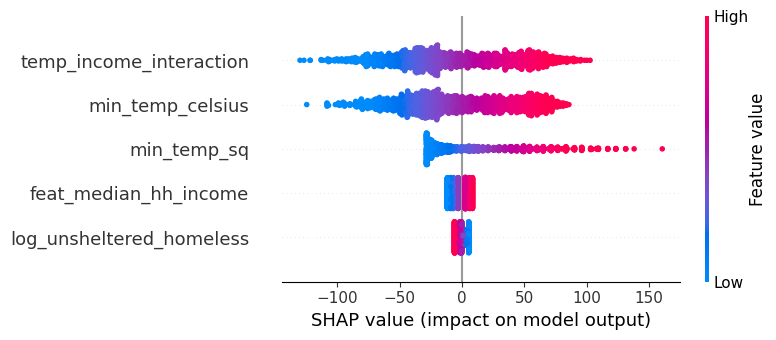

In [65]:
shap.summary_plot(shap_values, X_test_best)

9. SHAP Dependence Plot

Shows:

- How a feature affects predictions across its range
- Reveals nonlinear patterns + interactions

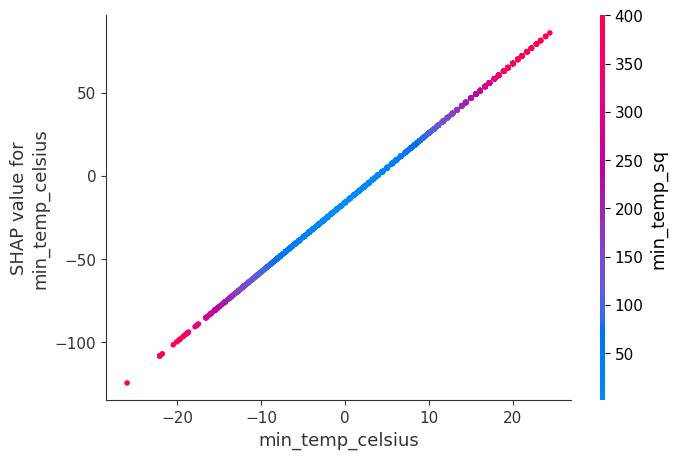

In [66]:
shap.dependence_plot(
    "min_temp_celsius",
    shap_values,
    X_test_best
)

Interpretation:

- The SHAP dependence plot for minimum temperature shows a strong positive and nearly linear relationship with HRI predictions.
- As temperature increases, its contribution to predicted heat-related illness also increases significantly.
- The coloring by the squared temperature term further reinforces the nonlinear effect, indicating that higher temperatures amplify the impact even more.
- This confirms that temperature is the dominant driver of HRI and that its effect intensifies at higher levels.


Key Takeaway:

Higher temperatures → disproportionately higher HRI (nonlinear effect)

10. SHAP Bar Plot

Shows:
- Which features matter
- Easy to explain

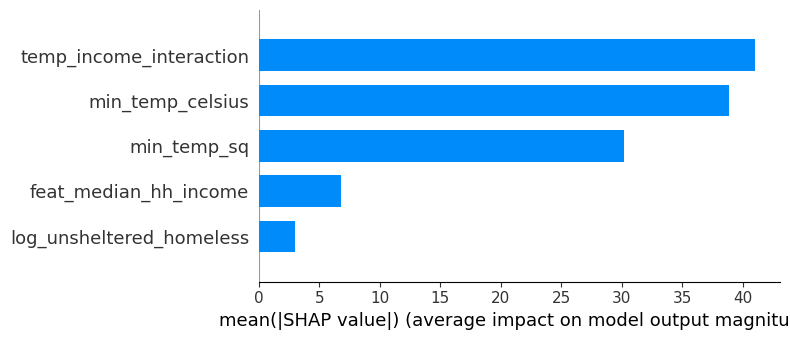

In [67]:
shap.summary_plot(shap_values, X_test_best, plot_type="bar")

Interpretation:

The SHAP bar plot highlights the relative importance of each feature in the model.
- The temperature-income interaction and minimum temperature are the most influential predictors, followed by the squared temperature term.
- Socioeconomic variables such as median household income and homelessness have smaller impacts.


This indicates that environmental factors, particularly temperature, play the largest role in predicting heat-related illness, while socioeconomic variables provide additional but less dominant context.


Key Takeaway:

Temperature-related features dominate model predictions

11. SHAP Waterfall Plot

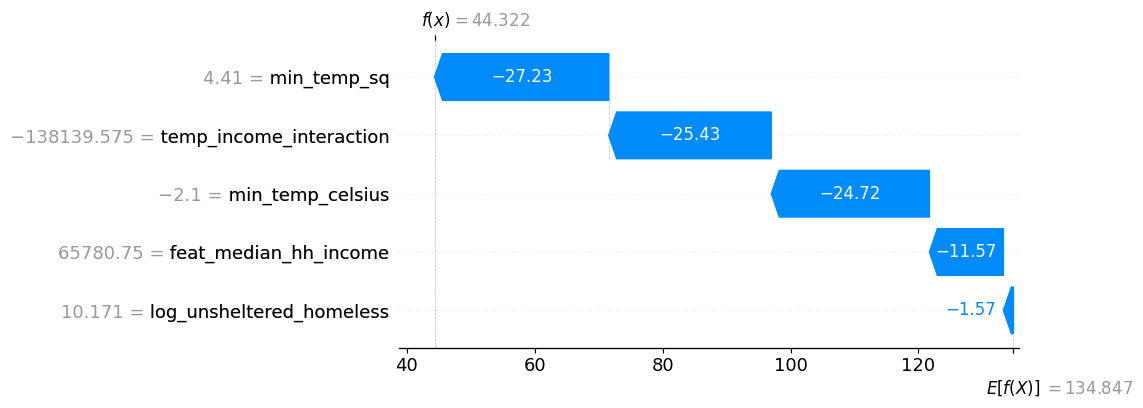

In [68]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_best.iloc[0],
        feature_names=X_test_best.columns
    )
)

Interpretation:

The SHAP waterfall plot illustrates how individual features contribute to a single prediction.
- Starting from the baseline (average prediction), each feature either increases or decreases the predicted HRI value.
- In this example, all features contribute negatively, pulling the prediction below the baseline.
- Temperature-related variables account for the largest changes, while socioeconomic variables contribute smaller adjustments.

This demonstrates how the model combines multiple feature effects to arrive at a final prediction.


Key Takeaway:

Prediction = baseline + sum of feature contributions

12. SHAP Decision Plot

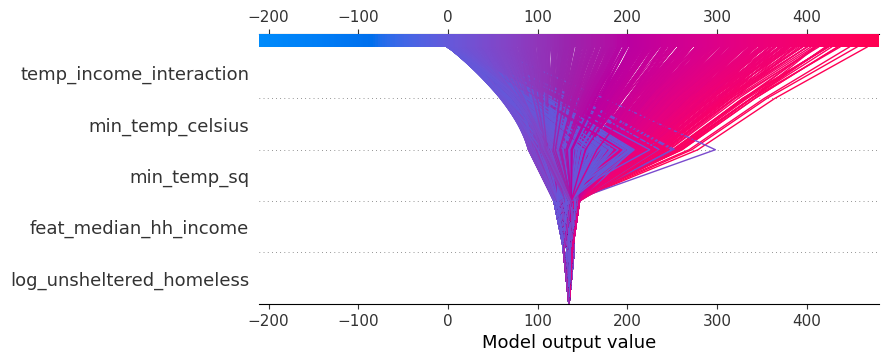

In [69]:
shap.decision_plot(
    explainer.expected_value,
    shap_values,
    X_test_best
)

Interpretation:

The SHAP decision plot shows how predictions are built across multiple observations by accumulating feature contributions.
- The spread of lines indicates variability in how features influence predictions across different data points.
- Temperature-related features consistently drive large changes in predictions, while other features contribute smaller adjustments.
- The wide spread at higher output values suggests that the model exhibits greater uncertainty and variability when predicting extreme HRI levels.


Key Takeaway:

Model is more variable/uncertain at high HRI values.

### SHAP Conclusion:

SHAP analysis was used to interpret both global and local behavior of the model. The results consistently show that temperature-related variables are the dominant drivers of heat-related illness predictions, with a clear nonlinear effect where higher temperatures lead to disproportionately larger increases in HRI. Socioeconomic variables, including income and homelessness, contribute smaller but meaningful adjustments. Local explanation plots further demonstrate how individual predictions are constructed from feature contributions, while global plots highlight variability and increased uncertainty at extreme values. Overall, SHAP analysis confirms that temperature is the primary factor influencing model predictions, with additional context provided by socioeconomic conditions.

# Conclusion

The engineered model improves predictive performance by capturing nonlinear temperature effects, though it still struggles with extreme HRI values.

The results indicate that temperature is the dominant driver of heat-related illness, with a nonlinear effect that accelerates at higher temperatures. While socioeconomic and homelessness variables contribute additional context, their influence is comparatively smaller. The model’s difficulty in predicting extreme values highlights the inherent complexity of real-world health outcomes and suggests potential areas for future improvement.